## 幸せの正体を探る
1254810984 藤永優多

### 1．幸福度を決める一番の要因はなにか
お金や健康、自由など、何が人の幸せに最も影響しているのか知りたいと思った。

### 2．データの読み込み

In [24]:
# 必要なライブラリをインポート
import pandas as pd
import matplotlib.pyplot as plt

# CSVファイルを読み込む
df = pd.read_csv('world_happiness_report.csv')

# データの最初の5行を表示
df.head()

,Unnamed: 0,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual,year
0,0,Switzerland,Western Europe,1.0,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738,2015
1,1,Iceland,Western Europe,2.0,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201,2015
2,2,Denmark,Western Europe,3.0,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204,2015
3,3,Norway,Western Europe,4.0,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531,2015
4,4,Canada,North America,5.0,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176,2015


In [25]:
# データの形状を確認（行数、列数）
print(f"データの形状: {df.shape}")

# データの基本情報
df.info()

データの形状: (1231, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1231 entries, 0 to 1230
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     1231 non-null   int64  
 1   Country                        617 non-null    object 
 2   Region                         315 non-null    object 
 3   Happiness Rank                 315 non-null    float64
 4   Happiness Score                315 non-null    float64
 5   Standard Error                 158 non-null    float64
 6   Economy (GDP per Capita)       315 non-null    float64
 7   Family                         470 non-null    float64
 8   Health (Life Expectancy)       315 non-null    float64
 9   Freedom                        470 non-null    float64
 10  Trust (Government Corruption)  315 non-null    float64
 11  Generosity                     1084 non-null   float64
 12  Dystopia Residual            

In [26]:
# 基本統計量を表示
df.describe()

,Unnamed: 0,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual,year
count,1231.000000,315.000000,315.000000,158.000000,315.000000,470.000000,315.000000,470.000000,315.000000,1084.000000,315.000000,1231.000000
mean,615.000000,79.238095,5.378949,0.047885,0.899837,0.990347,0.594054,0.402828,0.140532,0.153545,2.212032,2018.450041
std,355.503399,45.538922,1.141531,0.017146,0.410780,0.318707,0.240790,0.150356,0.115490,0.167592,0.558728,2.284034
min,0.000000,1.000000,2.839000,0.018480,0.000000,0.000000,0.000000,0.000000,0.000000,-0.300907,0.328580,2015.000000
25%,307.500000,40.000000,4.510000,0.037268,0.594900,0.793000,0.419645,0.297615,0.061315,0.064828,1.884135,2016.000000
50%,615.000000,79.000000,5.286000,0.043940,0.973060,1.025665,0.640450,0.418347,0.106130,0.162140,2.211260,2018.000000
75%,922.500000,118.500000,6.269000,0.052300,1.229000,1.228745,0.787640,0.516850,0.178610,0.252000,2.563470,2020.000000
max,1230.000000,158.000000,7.587000,0.136930,1.824270,1.610574,1.025250,0.669730,0.551910,0.838075,3.837720,2022.000000


### 3．分析

分析１：まず幸福度スコアと各要素（GDP・健康・自由など）の相関関係を調べ、グラフにしていく。

C:\Users\donbu\AppData\Local\Temp\ipykernel_31340\2179233276.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlation.values, y=correlation.index, palette='viridis')


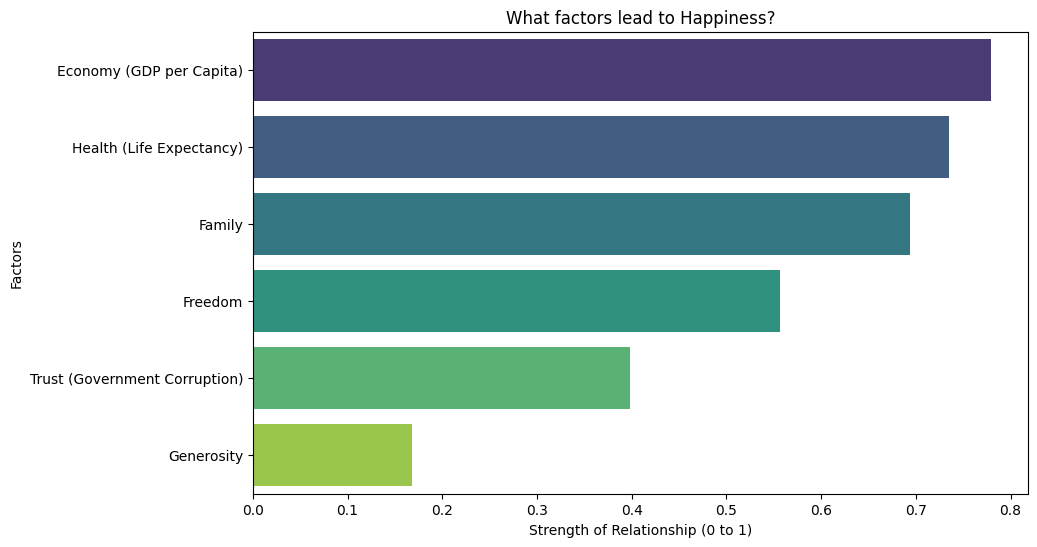

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# データを読み込む
df = pd.read_csv('world_happiness_report.csv')

# 分析に使う項目（幸福度と、その理由となる6項目）
cols = ['Happiness Score', 'Economy (GDP per Capita)', 'Family', 
        'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity']

# 1. データの準備（数値データのみ、空欄は消去）
data_clean = df[cols].dropna()

# 2. 相関係数（連動率）を計算
correlation = data_clean.corr()['Happiness Score'].sort_values(ascending=False).drop('Happiness Score')

# 3. グラフを描く設定
plt.figure(figsize=(10, 6))
sns.barplot(x=correlation.values, y=correlation.index, palette='viridis')

# グラフのタイトルやラベル
plt.title('What factors lead to Happiness?')
plt.xlabel('Strength of Relationship (0 to 1)')
plt.ylabel('Factors')
plt.show()

とくに経済の貢献度、健康、家族が幸福につながっていることがわかる。

分析２：幸福度の高い国とそうでない国では、具体的にどのくらい数字が違うのかを調べる。各要素で上位10か国の平均と下位10か国の平均の数値を比較する。

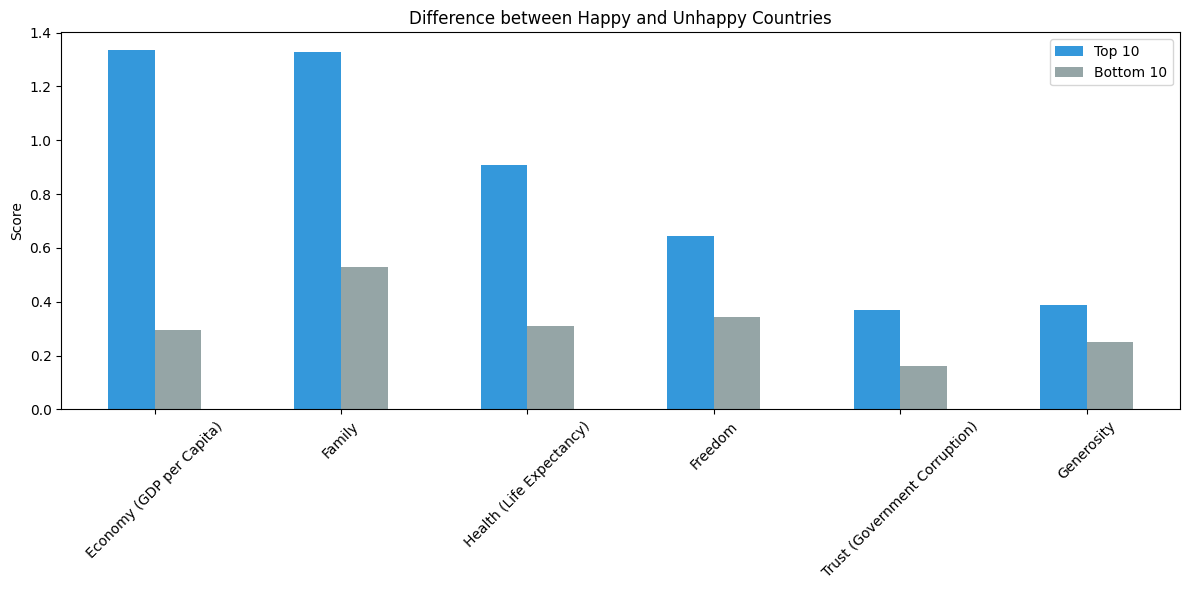

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

# データを読み込む
df = pd.read_csv('world_happiness_report.csv')

# 分析項目
factor_cols = ['Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 
               'Freedom', 'Trust (Government Corruption)', 'Generosity']

# 1. 2015年のデータを使用（このデータセットで最も数値が揃っている年です）
analysis_df = df[df['year'] == 2015].dropna(subset=['Happiness Score'])

# 2. 上位10カ国と下位10カ国の平均
top_10_avg = analysis_df.nlargest(10, 'Happiness Score')[factor_cols].mean()
bottom_10_avg = analysis_df.nsmallest(10, 'Happiness Score')[factor_cols].mean()

# 3. グラフ作成
plt.figure(figsize=(12, 6)) # 新しいウィンドウを明示的に作成
comparison_df = pd.DataFrame({'Top 10': top_10_avg, 'Bottom 10': bottom_10_avg})
comparison_df.plot(kind='bar', color=['#3498db', '#95a5a6'], ax=plt.gca())

plt.title('Difference between Happy and Unhappy Countries')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

# グラフを画面に表示させるための命令
plt.show()

幸福度の高い国と低い国では、分析1で幸福のおもな理由となっていた経済や家族、健康でかなり差があることがわかる。
寛容さではあまり差が見られなかった。

分析３：国のタイプ分けをしていく。

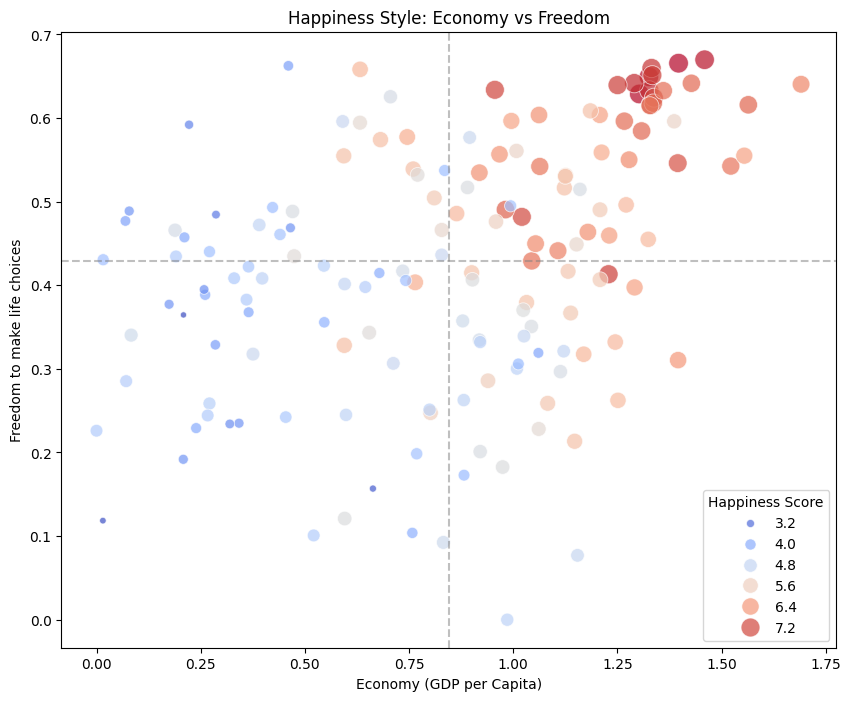

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 2015年のデータを使用
df_2015 = df[df['year'] == 2015].dropna(subset=['Economy (GDP per Capita)', 'Freedom', 'Happiness Score'])

# 2. 経済と自由の「平均値」を基準線にする
gdp_mean = df_2015['Economy (GDP per Capita)'].mean()
freedom_mean = df_2015['Freedom'].mean()

# 3. 散布図を作成
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_2015, x='Economy (GDP per Capita)', y='Freedom', 
                size='Happiness Score', hue='Happiness Score', 
                palette='coolwarm', sizes=(20, 200), alpha=0.7)

# 4. 平均値の線（十字）を引いて4つのエリアに分ける
plt.axvline(gdp_mean, color='gray', linestyle='--', alpha=0.5)
plt.axhline(freedom_mean, color='gray', linestyle='--', alpha=0.5)

# 5. ラベルとタイトル
plt.title('Happiness Style: Economy vs Freedom')
plt.xlabel('Economy (GDP per Capita)')
plt.ylabel('Freedom to make life choices')

plt.show()

このグラフでは右上が経済・自由も高い国、左上は自由は高いが経済が低い国、右下が経済は高いが自由が低い国になっている。
やはり、両方が高い国は幸福度のスコアも高い国が多い。右下と左上だと、右下の方が幸福度の高い国が多いことがわかる。

### 結論

幸せにはお金や健康といった生活の土台が大切であることがわかった。しかし、幸福度の高い国は家族の支えや自由も同じくらい持っていた。このことから経済的な豊かさだけでなく、心や人とのつながりを大切にできる社会にしていくことが必要だと感じました。